Saved plot to: 1Hz.png


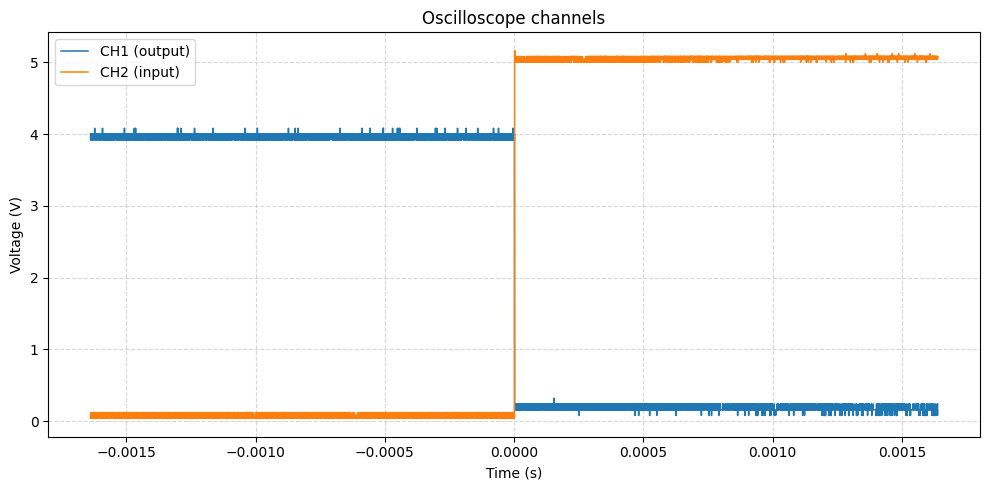

In [11]:
#!/usr/bin/env python3
"""
Plot oscilloscope data from CSV file.

This script:
 - Reads CSV data with format: <empty>,<empty>,<empty>,<time>,<ch1_volt>,<ch2_volt>
 - Plots CH1 and CH2 vs time, with labels, legend, grid, and saves a PNG.
"""

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

def parse_csv_data(path: Path):
    """Return numpy arrays (t, ch1, ch2) from CSV file."""
    times = []
    ch1 = []
    ch2 = []
    
    with path.open('r', encoding='utf-8', errors='replace') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            try:
                # Skip first 3 empty columns, read time, ch1, ch2
                t = float(parts[3])
                v1 = float(parts[4])
                v2 = float(parts[5])
                times.append(t)
                ch1.append(v1)
                ch2.append(v2)
            except (ValueError, IndexError):
                continue
    
    if len(times) == 0:
        raise ValueError(f"No numeric data rows found in file {path}")
    
    t = np.array(times, dtype=float)
    v1 = np.array(ch1, dtype=float)
    v2 = np.array(ch2, dtype=float)
    return t, v1, v2


def plot_and_save(t, ch1, ch2, out_png: Path):
    plt.figure(figsize=(10, 5))
    plt.plot(t, ch1, label='CH1 (output)', linewidth=1.1)
    plt.plot(t, ch2, label='CH2 (input)', linewidth=1.1)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage (V)')
    plt.title('Oscilloscope channels')
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    print(f"Saved plot to: {out_png}")
    plt.show()
    plt.close()


# Main execution
csv_path = Path('1Hz.CSV')
if not csv_path.exists():
    raise FileNotFoundError(f"File not found: {csv_path}")

t, v1, v2 = parse_csv_data(csv_path)

# Sort by time
order = np.argsort(t)
t = t[order]
v1 = v1[order]
v2 = v2[order]

out_path = csv_path.with_suffix('.png')
plot_and_save(t, v1, v2, out_path)


In [12]:
# Determine rise and fall times for CH1 (output) with respect to CH2 (input)

def find_transitions(t, v, threshold_low=1.0, threshold_high=4.0):
    """
    Find rising and falling edge times based on threshold crossings.
    Returns lists of (time, type) tuples where type is 'rise' or 'fall'.
    """
    transitions = []
    state = 'low' if v[0] < threshold_low else 'high'
    
    for i in range(1, len(v)):
        if state == 'low' and v[i] > threshold_high:
            # Rising edge
            transitions.append((t[i], 'rise'))
            state = 'high'
        elif state == 'high' and v[i] < threshold_low:
            # Falling edge
            transitions.append((t[i], 'fall'))
            state = 'low'
    
    return transitions

# Find transitions for both channels
ch1_transitions = find_transitions(t, v1)
ch2_transitions = find_transitions(t, v2)

print("CH2 (input) transitions:")
for time, edge_type in ch2_transitions[:10]:  # Show first 10
    print(f"  {edge_type:5s} at t = {time*1e6:.3f} µs")

print("\nCH1 (output) transitions:")
for time, edge_type in ch1_transitions[:10]:  # Show first 10
    print(f"  {edge_type:5s} at t = {time*1e6:.3f} µs")

# Calculate propagation delays (rise and fall times)
rise_delays = []
fall_delays = []

for ch2_time, ch2_type in ch2_transitions:
    # Find corresponding CH1 transition of same type
    for ch1_time, ch1_type in ch1_transitions:
        if ch1_type == ch2_type and ch1_time > ch2_time:
            delay = ch1_time - ch2_time
            if ch2_type == 'rise':
                rise_delays.append(delay)
            else:
                fall_delays.append(delay)
            break

if rise_delays:
    print(f"\nRise time delays (CH2→CH1): {np.mean(rise_delays)*1e9:.2f} ± {np.std(rise_delays)*1e9:.2f} ns")
if fall_delays:
    print(f"Fall time delays (CH2→CH1): {np.mean(fall_delays)*1e9:.2f} ± {np.std(fall_delays)*1e9:.2f} ns")


CH2 (input) transitions:
  rise  at t = 1.600 µs

CH1 (output) transitions:
  fall  at t = 1.600 µs
